# Introduction
FiveThirtyEight has a potty-mouthed data set of all swear words said in Tarantino's feature-length films up to <i>Django Unchained</i>, `tarantino`. We will supplement the `tarantino` data set with `tarantino_omdb`, which contains peripheral movie information such as genre, awards, and ratings pulled from the Online Movie Date Base via API. In this notebook, we will perform an exploratory data analysis of these two data sets to elicit any interesting data patterns.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

In [2]:
# # Install ff libraries as needed
# !pip install morethemes
# !pip install nltk

In [26]:
# Set theme
import morethemes as mt

mt.set_theme("vscode-dark")

# For grouping similar swear words together
import nltk

# # Will only need to be locally downloaded once
# nltk.download("wordnet")
# nltk.download("averaged_perceptron_tagger")  # Optional but recommended

# Data Cleaning

In [4]:
url = (
    "https://raw.githubusercontent.com/fivethirtyeight"
    "/data/master/tarantino/tarantino.csv"
)
df = pd.read_csv(url)
df.head()

,movie,type,word,minutes_in
0,Reservoir Dogs,word,dick,0.40
1,Reservoir Dogs,word,dicks,0.43
2,Reservoir Dogs,word,fucked,0.55
3,Reservoir Dogs,word,fucking,0.61
4,Reservoir Dogs,word,bullshit,0.61


The data set contains the following features:
- `movie` : movie title
- `type` : word or death
- `word` : if word, what word
- `minutes_in` : how many minutes into `movie` word or death occurred

In [5]:
df.shape

(1894, 4)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1894 entries, 0 to 1893
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   movie       1894 non-null   str    
 1   type        1894 non-null   str    
 2   word        1704 non-null   str    
 3   minutes_in  1894 non-null   float64
dtypes: float64(1), str(3)
memory usage: 59.3 KB


In [7]:
colnames = list(df.columns)

for col in colnames:
    print(df[col].unique())

<StringArray>
[     'Reservoir Dogs',        'Pulp Fiction',   'Kill Bill: Vol. 1',
   'Kill Bill: Vol. 2', 'Inglorious Basterds',    'Django Unchained',
        'Jackie Brown']
Length: 7, dtype: str
<StringArray>
['word', 'death']
Length: 2, dtype: str
<StringArray>
[         'dick',         'dicks',        'fucked',       'fucking',
      'bullshit',          'fuck',          'shit',  'motherfucker',
         'pussy',         'fucks',          'hell',           'jap',
       'bastard',       'goddamn', 'motherfuckers',       'asshole',
           'ass',      'assholes',       'n-word ',         'asses',
         'bitch',        'fuckup',        'fucker',        'shitty',
       'asshead',          'damn',             nan,        'damned',
       'bitches',       'wetback',        'faggot',    'cocksucker',
          'gook',       'fuckers',         'gooks', 'motherfucking',
      'dickless',   'chickenshit',         'slope',      'fuckhead',
         'merde',      'shithead',        

The movies are all Tarantino feature-length films from <i>Reservoir Dogs</i> released in 1991 to <i>Django Unchained</i> release in 2012.

## One-Hot Encoding
For counting, it's useful to convert `type` to <a href="https://www.geeksforgeeks.org/machine-learning/one-hot-encoding-from-a-pandas-column-containing-a-list/">one-hot encoded</a> categories. That is, take the categories under `type` ('word' and 'death') and turn them to their own columns, then each row will simply contain either 1 or 0 for presence or absence.

In [10]:
type_categories = df["type"].unique()

for category in type_categories:
    df[category] = df["type"].apply(lambda x: 1 if category in x else 0)

df.head()

,movie,type,word,minutes_in,word_lemma,death
0,Reservoir Dogs,word,1,0.40,dick,0
1,Reservoir Dogs,word,1,0.43,dick,0
2,Reservoir Dogs,word,1,0.55,fuck,0
3,Reservoir Dogs,word,1,0.61,fuck,0
4,Reservoir Dogs,word,1,0.61,bullshit,0


## Lemmatizing

There are 60 unique `word` strings (and 1 NaN), but note that several words are variants of a root (i.e., "fucked", "fucking" are variants of root word "fuck"). For counting word frequency down the line, we are interested in simplifying words down to their roots. For this, we will use `WordNetLemmatizer` from the `nltk` module. Documentation <a href="https://www.nltk.org/api/nltk.stem.wordnet.html">here</a>.

In [8]:
from nltk.stem import WordNetLemmatizer


def lemmatize_word(x):
    lemmatizer = WordNetLemmatizer()
    if pd.notna(x):
        # Try as noun first, then verb
        noun_lemma = lemmatizer.lemmatize(x, pos="n")
        verb_lemma = lemmatizer.lemmatize(noun_lemma, pos="v")
        return verb_lemma
    return None


df["word_lemma"] = df["word"].str.lower().apply(lemmatize_word)

overrides = {"as": "ass"}

df["word_lemma"] = df["word_lemma"].map(lambda x: overrides.get(x, x))

df.head(10)

,movie,type,word,minutes_in,word_lemma
0,Reservoir Dogs,word,dick,0.40,dick
1,Reservoir Dogs,word,dicks,0.43,dick
2,Reservoir Dogs,word,fucked,0.55,fuck
3,Reservoir Dogs,word,fucking,0.61,fuck
4,Reservoir Dogs,word,bullshit,0.61,bullshit
5,Reservoir Dogs,word,fuck,0.66,fuck
6,Reservoir Dogs,word,shit,0.90,shit
7,Reservoir Dogs,word,fuck,1.43,fuck
8,Reservoir Dogs,word,dicks,1.56,dick
9,Reservoir Dogs,word,fuck,1.66,fuck


In [9]:
# # Optional, to save df as csv and view the whole data set
df.to_csv("tarantino.csv", index=False)

# Creating Histogram of Swears and Death

In [41]:
# Save theme rcparams to variable
vscode_dark_rcparams = mt.get_rcparams("vscode-dark")

In [42]:
from typing import List

from cycler import Cycler


def get_cycler_colors(cycler: Cycler) -> List[str]:
    """
    Extract color values from a Cycler object.

    A Cycler object (typically from matplotlib.rcParams['axes.prop_cycler'])
    contains a sequence of property dictionaries. This function extracts only
    the 'color' key from each dictionary.

    Parameters
    ----------
    cycler : Cycler
        A matplotlib Cycler object containing color specifications.
        Typically accessed via `plt.rcParams['axes.prop_cycler']`.

    Returns
    -------
    palette : list of str
        List of color values (hex codes or named colors) in order.

    Raises
    ------
    ValueError
        If the Cycler contains no 'color' key in its dictionaries.

    Examples
    --------
    >>> import matplotlib.pyplot as plt
    >>> cycler_obj = plt.rcParams['axes.prop_cycler']
    >>> colors = get_cycler_colors(cycler_obj)
    >>> print(colors)
    ['#1f77b4', '#ff7f0e', '#2ca02c', ...]
    """
    if not cycler:
        return []

    palette = [d.get("color") for d in cycler if "color" in d]

    if not palette:
        raise ValueError("Cycler object contains no 'color' key")

    return palette

In [ ]:
# Get the color palette
palette = get_cycler_colors(vscode_dark_rcparams["axes.prop_cycle"])

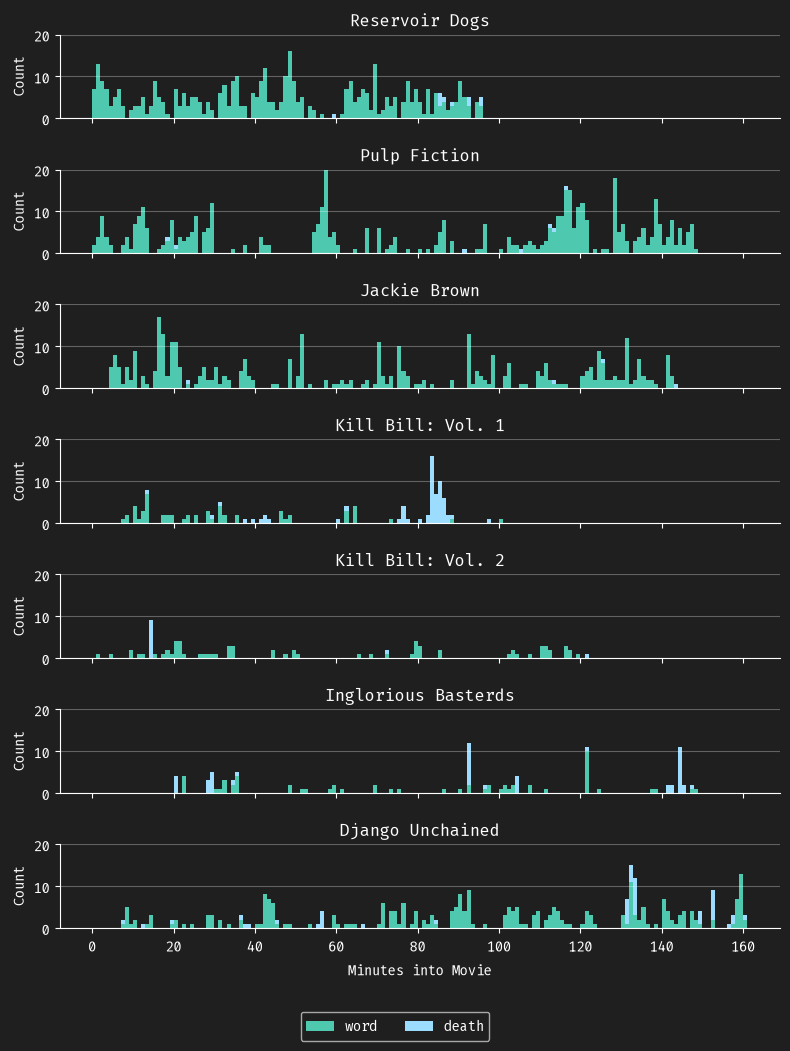

In [136]:
# Declare movie order by year of release
movie_order = [
    "Reservoir Dogs",
    "Pulp Fiction",
    "Jackie Brown",
    "Kill Bill: Vol. 1",
    "Kill Bill: Vol. 2",
    "Inglorious Basterds",
    "Django Unchained",
]

# Create subplots (7 movies = 7 rows)
fig, axes = plt.subplots(len(movie_order), 1, figsize=(8, 10), sharex=True)

for idx, movie in enumerate(movie_order):
    # Filter df so that you only get rows specific to the movie
    movie_data = df[df["movie"] == movie]

    # Adjust max_minute value to film length(-ish) + 1
    max_minutes = int(movie_data["minutes_in"].max()) + 1

    # Adjust bin range to the film length(-ish)
    # Change to this if I want bins to be every 5 mins
    # bins=range(0, int(df['minutes_in'].max()) + 6, 5)
    bins = range(0, max_minutes + 1)

    # Take the time stamp where swearing or death occurred
    word_mins = movie_data[movie_data["type"] == "word"]["minutes_in"]
    death_mins = movie_data[movie_data["type"] == "death"]["minutes_in"]

    # Create a histogram that stacks word and swearing occurrences
    axes[idx].hist(
        [word_mins, death_mins], bins=bins, stacked=True, label=["word", "death"]
    )

    axes[idx].set_ylabel("Count")
    axes[idx].set_title(movie)
    axes[idx].set_ylim(0, 20)
    axes[idx].grid(axis="y", alpha=0.3)

axes[-1].set_xlabel("Minutes into Movie")

# Change legend to a better position later lol
fig.legend(["word", "death"], loc="upper center", bbox_to_anchor=(0.5, -0.01), ncol=2)
plt.tight_layout()
plt.savefig("word-death-runtime-hist.png", dpi=300, bbox_inches="tight")
plt.show()

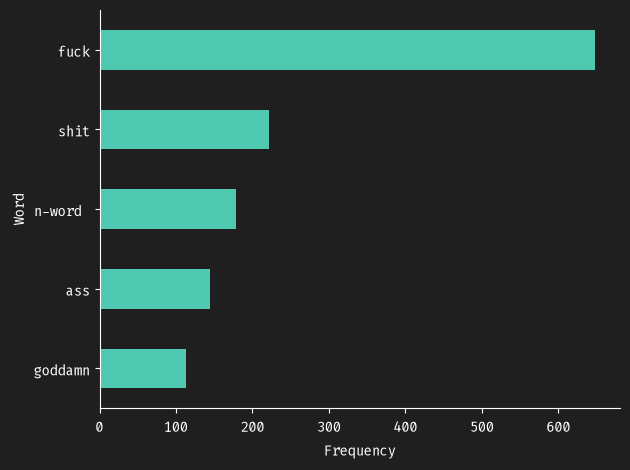

In [47]:
swearwords = list(df[df["type"] == "word"]["word_lemma"].unique())

word_counts = (
    df[df["type"] == "word"]["word_lemma"]
    .value_counts()
    .head(5)
    .sort_values(ascending=True)
)
word_counts.plot(kind="barh")
plt.xlabel("Frequency")
plt.ylabel("Word")
# plt.title("Top 10 Word Frequencies")
plt.tight_layout()
plt.show()

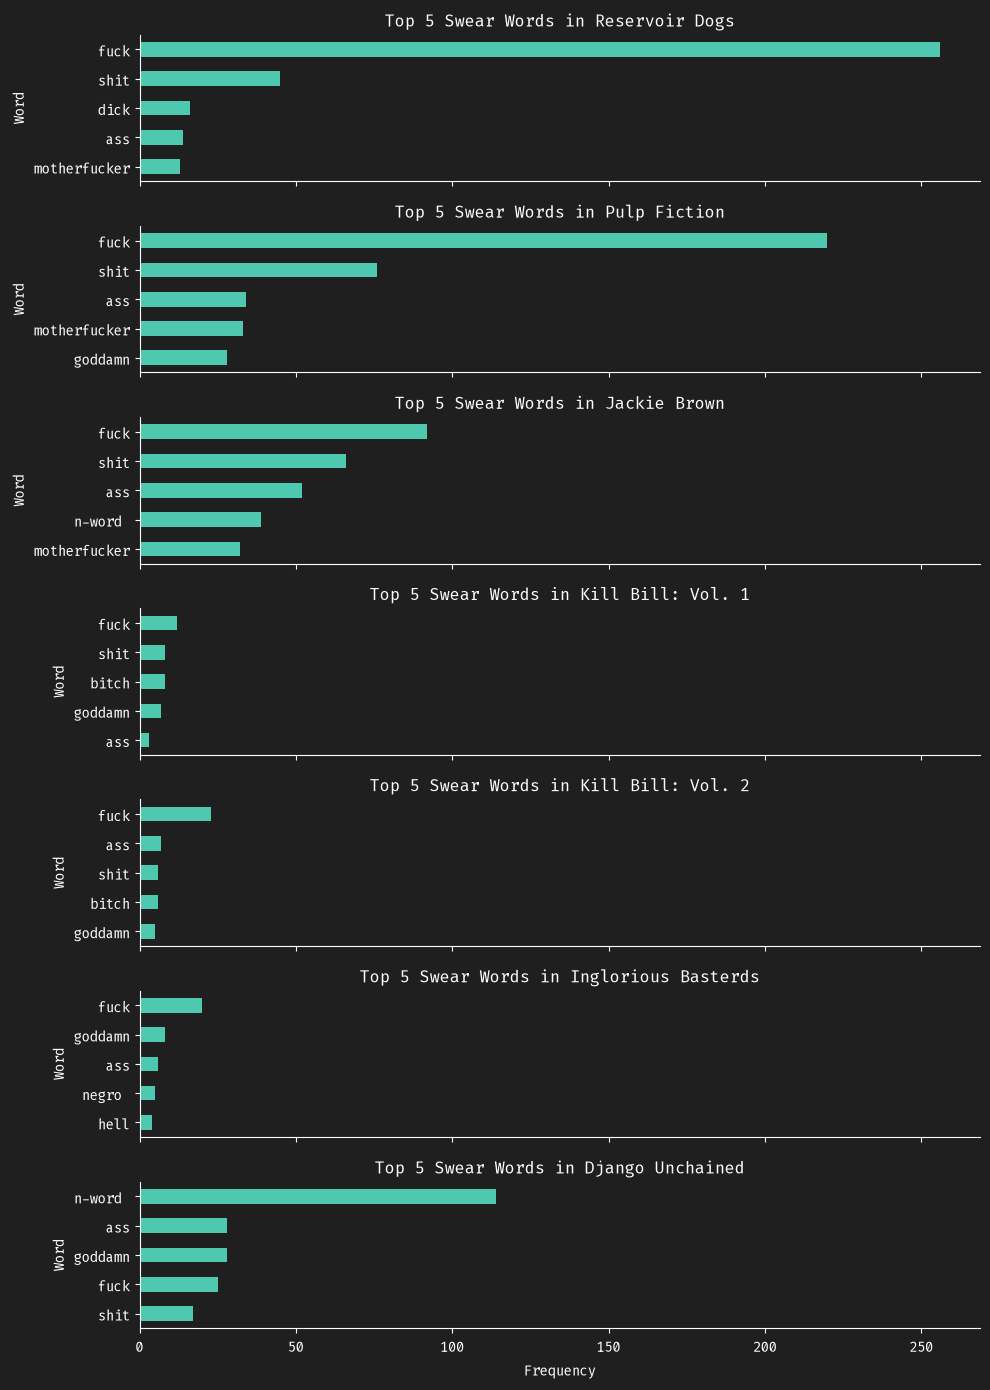

In [51]:
# Get unique movies
movies = df["movie"].unique()

# Create subplots (adjust nrows/ncols based on number of movies)
fig, axes = plt.subplots(
    nrows=len(movies), ncols=1, figsize=(10, 2 * len(movies)), sharex=True
)

for idx, movie in enumerate(movie_order):
    word_counts = (
        df[(df["type"] == "word") & (df["movie"] == movie)]["word_lemma"]
        .value_counts()
        .head(5)
        .sort_values(ascending=True)
    )
    word_counts.plot(kind="barh", ax=axes[idx])
    axes[idx].set_xlabel("Frequency")
    axes[idx].set_ylabel("Word")
    axes[idx].set_title(f"Top 5 Swear Words in {movie}")

plt.tight_layout()
plt.show()

# Relating Swear & Death Count to Box Office Returns

In [80]:
path = "tarantino_omdb.csv"
df_omdb = pd.read_csv(path)
df_omdb.columns

Index(['Title', 'Year', 'IMDb ID', 'MPAA Rating', 'Runtime (minutes)', 'Genre',
       'Plot', 'Box Office', 'IMDb Rating', 'Awards',
       'Internet Movie Database', 'Rotten Tomatoes', 'Metacritic'],
      dtype='str')

In [81]:
violence_cnt = df.groupby("movie")["type"].count().to_dict()
violence_cnt = {movie: violence_cnt[movie] for movie in movie_order}

In [96]:
swear_cnt = df.groupby("movie")["word"].sum().to_dict()
swear_cnt = {movie: swear_cnt[movie] for movie in movie_order}

In [97]:
death_cnt = df.groupby("movie")["death"].sum().to_dict()
death_cnt = {movie: death_cnt[movie] for movie in movie_order}

In [98]:
temp_df = pd.DataFrame(
    {
        "movie": movie_order,
        "violence_cnt": [violence_cnt[movie] for movie in movie_order],
        "swear_cnt": [swear_cnt[movie] for movie in movie_order],
        "death_cnt": [death_cnt[movie] for movie in movie_order],
    }
)
temp_df

,movie,violence_cnt,swear_cnt,death_cnt
0,Reservoir Dogs,431,421,10
1,Pulp Fiction,476,469,7
2,Jackie Brown,372,368,4
3,Kill Bill: Vol. 1,120,57,63
4,Kill Bill: Vol. 2,80,69,11
5,Inglorious Basterds,106,58,48
6,Django Unchained,309,262,47


In [99]:
df_vio_bo = temp_df.merge(
    df_omdb[["Title", "Year", "Box Office"]], left_on="movie", right_on="Title"
)
df_vio_bo.drop("Title", axis=1, inplace=True)

In [100]:
df_vio_bo.columns

Index(['movie', 'violence_cnt', 'swear_cnt', 'death_cnt', 'Year',
       'Box Office'],
      dtype='str')

In [103]:
df_vio_bo.columns = [
    "movie",
    "violence_cnt",
    "swear_cnt",
    "death_cnt",
    "year",
    "box_office",
]
df_vio_bo

,movie,violence_cnt,swear_cnt,death_cnt,year,box_office
0,Reservoir Dogs,431,421,10,1992,2832029
1,Pulp Fiction,476,469,7,1994,107928762
2,Jackie Brown,372,368,4,1997,39673162
3,Kill Bill: Vol. 1,120,57,63,2003,70099045
4,Kill Bill: Vol. 2,80,69,11,2004,66208183
5,Django Unchained,309,262,47,2012,162805434


In [104]:
# Accounting for inflation (to 2026)
# Inflation factors from https://www.usinflationcalculator.com/
inflation_factor = {
    1992: 2.38,
    1994: 2.25,
    1997: 2.08,
    2003: 1.81,
    2004: 1.77,
    2012: 1.45,
}

In [105]:
df_vio_bo["box_office_adjusted"] = df_vio_bo.apply(
    lambda row: row["box_office"] * inflation_factor[row["year"]], axis=1
)
df_vio_bo

,movie,violence_cnt,swear_cnt,death_cnt,year,box_office,box_office_adjusted
0,Reservoir Dogs,431,421,10,1992,2832029,6.740229e+06
1,Pulp Fiction,476,469,7,1994,107928762,2.428397e+08
2,Jackie Brown,372,368,4,1997,39673162,8.252018e+07
3,Kill Bill: Vol. 1,120,57,63,2003,70099045,1.268793e+08
4,Kill Bill: Vol. 2,80,69,11,2004,66208183,1.171885e+08
5,Django Unchained,309,262,47,2012,162805434,2.360679e+08


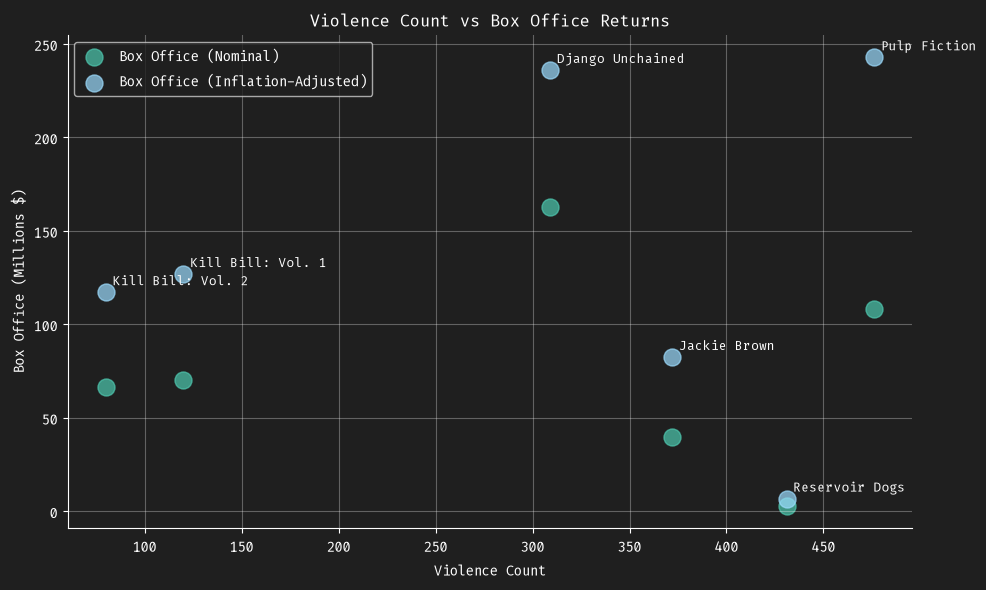

In [110]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot original box office
ax.scatter(
    df_vio_bo["violence_cnt"],
    df_vio_bo["box_office"] / 1e6,
    s=150,
    alpha=0.7,
    label="Box Office (Nominal)",
    color=palette[0],
)

# Plot adjusted box office
ax.scatter(
    df_vio_bo["violence_cnt"],
    df_vio_bo["box_office_adjusted"] / 1e6,
    s=150,
    alpha=0.7,
    label="Box Office (Inflation-Adjusted)",
    color=palette[1],
)

# Annotate adjusted values (use adjusted to avoid clutter)
for idx, row in df_vio_bo.iterrows():
    ax.annotate(
        row["movie"],
        (row["violence_cnt"], row["box_office_adjusted"] / 1e6),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

ax.set_xlabel("Violence Count")
ax.set_ylabel("Box Office (Millions $)")
ax.set_title("Violence Count vs Box Office Returns")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("violence-vs-bo-returns.png", dpi=300, bbox_inches="tight")
plt.show()

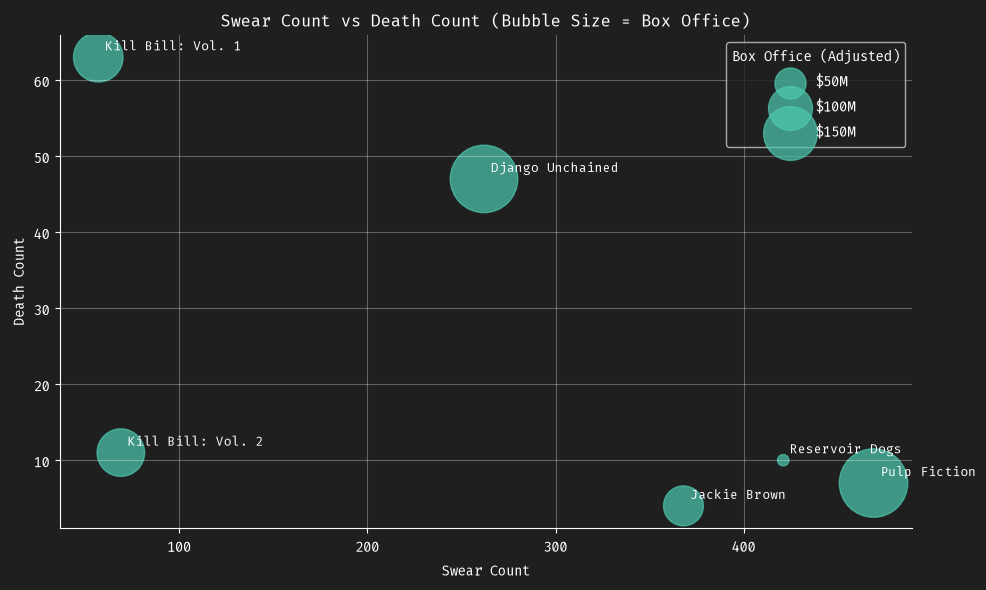

In [122]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_vio_bo["swear_cnt"],
    df_vio_bo["death_cnt"],
    s=df_vio_bo["box_office_adjusted"] / 1e5,
    alpha=0.7,
    color=palette[0],
)

# Add movie labels
for idx, row in df_vio_bo.iterrows():
    ax.annotate(row['movie'], (row['swear_cnt'], row['death_cnt']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax.set_xlabel("Swear Count")
ax.set_ylabel("Death Count")
ax.set_title("Swear Count vs Death Count (Bubble Size = Box Office)")
ax.grid(alpha=0.3)

# Add size legend
sizes = [50e6, 100e6, 150e6]
size_labels = ["$50M", "$100M", "$150M"]
legend_bubbles = [plt.scatter([], [], s=size/1e5, color=palette[0], alpha=0.7) for size in sizes]
ax.legend(legend_bubbles, size_labels, title="Box Office (Adjusted)", loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

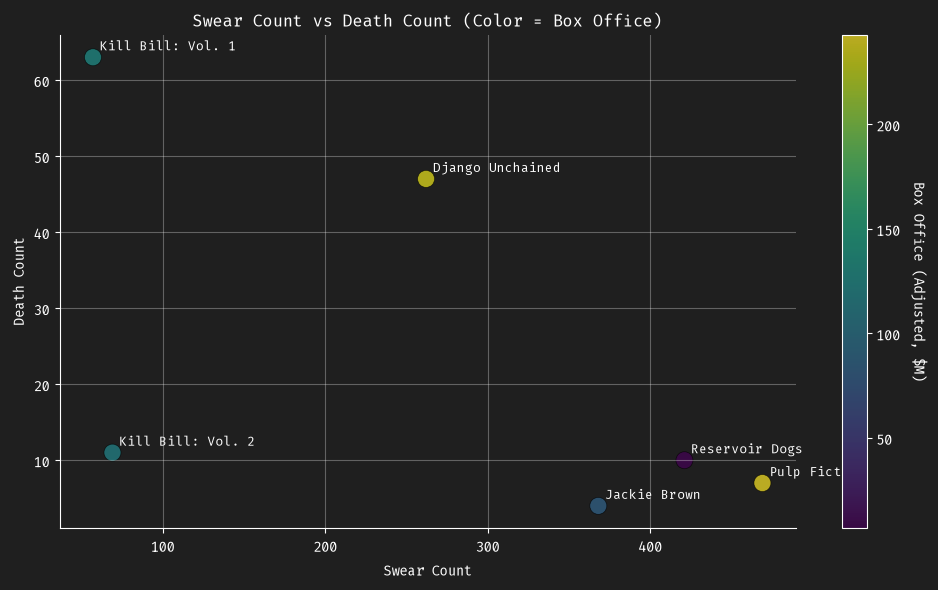

In [123]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_vio_bo["swear_cnt"],
    df_vio_bo["death_cnt"],
    s=150,  # constant bubble size for clarity
    c=df_vio_bo["box_office_adjusted"] / 1e6,  # color by box office (in millions)
    cmap="viridis",
    alpha=0.7,
    edgecolors="black",
    linewidth=0.5,
)

# Add movie labels
for idx, row in df_vio_bo.iterrows():
    ax.annotate(row['movie'], (row['swear_cnt'], row['death_cnt']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax.set_xlabel("Swear Count")
ax.set_ylabel("Death Count")
ax.set_title("Swear Count vs Death Count (Color = Box Office)")
ax.grid(alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Box Office (Adjusted, $M)", rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

# Bubble Chart

In [37]:
word_counts = (
    df[df["type"] == "word"]["word_lemma"].value_counts().sort_values(ascending=False)
)
word_counts.head()

word_lemma
fuck       648
shit       222
n-word     179
ass        144
goddamn    113
Name: count, dtype: int64

In [39]:
class BubbleChart:
    def __init__(self, area, bubble_spacing=0):
        """
        Setup for bubble collapse.

        Parameters
        ----------
        area : array-like
            Area of the bubbles.
        bubble_spacing : float, default: 0
            Minimal spacing between bubbles after collapsing.

        Notes
        -----
        If "area" is sorted, the results might look weird.
        """
        area = np.asarray(area)
        r = np.sqrt(area / np.pi)

        self.bubble_spacing = bubble_spacing
        self.bubbles = np.ones((len(area), 4))
        self.bubbles[:, 2] = r
        self.bubbles[:, 3] = area
        self.maxstep = 2 * self.bubbles[:, 2].max() + self.bubble_spacing
        self.step_dist = self.maxstep / 2

        # calculate initial grid layout for bubbles
        length = np.ceil(np.sqrt(len(self.bubbles)))
        grid = np.arange(length) * self.maxstep
        gx, gy = np.meshgrid(grid, grid)
        self.bubbles[:, 0] = gx.flatten()[: len(self.bubbles)]
        self.bubbles[:, 1] = gy.flatten()[: len(self.bubbles)]

        self.com = self.center_of_mass()

    def center_of_mass(self):
        return np.average(self.bubbles[:, :2], axis=0, weights=self.bubbles[:, 3])

    def center_distance(self, bubble, bubbles):
        return np.hypot(bubble[0] - bubbles[:, 0], bubble[1] - bubbles[:, 1])

    def outline_distance(self, bubble, bubbles):
        center_distance = self.center_distance(bubble, bubbles)
        return center_distance - bubble[2] - bubbles[:, 2] - self.bubble_spacing

    def check_collisions(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return len(distance[distance < 0])

    def collides_with(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return np.argmin(distance, keepdims=True)

    def collapse(self, n_iterations=50):
        """
        Move bubbles to the center of mass.

        Parameters
        ----------
        n_iterations : int, default: 50
            Number of moves to perform.
        """
        for _i in range(n_iterations):
            moves = 0
            for i in range(len(self.bubbles)):
                rest_bub = np.delete(self.bubbles, i, 0)
                # try to move directly towards the center of mass
                # direction vector from bubble to the center of mass
                dir_vec = self.com - self.bubbles[i, :2]

                # shorten direction vector to have length of 1
                dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))

                # calculate new bubble position
                new_point = self.bubbles[i, :2] + dir_vec * self.step_dist
                new_bubble = np.append(new_point, self.bubbles[i, 2:4])

                # check whether new bubble collides with other bubbles
                if not self.check_collisions(new_bubble, rest_bub):
                    self.bubbles[i, :] = new_bubble
                    self.com = self.center_of_mass()
                    moves += 1
                else:
                    # try to move around a bubble that you collide with
                    # find colliding bubble
                    for colliding in self.collides_with(new_bubble, rest_bub):
                        # calculate direction vector
                        dir_vec = rest_bub[colliding, :2] - self.bubbles[i, :2]
                        dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))
                        # calculate orthogonal vector
                        orth = np.array([dir_vec[1], -dir_vec[0]])
                        # test which direction to go
                        new_point1 = self.bubbles[i, :2] + orth * self.step_dist
                        new_point2 = self.bubbles[i, :2] - orth * self.step_dist
                        dist1 = self.center_distance(self.com, np.array([new_point1]))
                        dist2 = self.center_distance(self.com, np.array([new_point2]))
                        new_point = new_point1 if dist1 < dist2 else new_point2
                        new_bubble = np.append(new_point, self.bubbles[i, 2:4])
                        if not self.check_collisions(new_bubble, rest_bub):
                            self.bubbles[i, :] = new_bubble
                            self.com = self.center_of_mass()

            if moves / len(self.bubbles) < 0.1:
                self.step_dist = self.step_dist / 2

    def plot(self, ax, labels, colors):
        """
        Draw the bubble plot.

        Parameters
        ----------
        ax : matplotlib.axes.Axes
        labels : list
            Labels of the bubbles.
        colors : list
            Colors of the bubbles.
        """
        for i in range(len(self.bubbles)):
            circ = plt.Circle(self.bubbles[i, :2], self.bubbles[i, 2], color=colors[i])
            ax.add_patch(circ)
            ax.text(
                *self.bubbles[i, :2],
                labels[i],
                horizontalalignment="center",
                verticalalignment="center"
            )

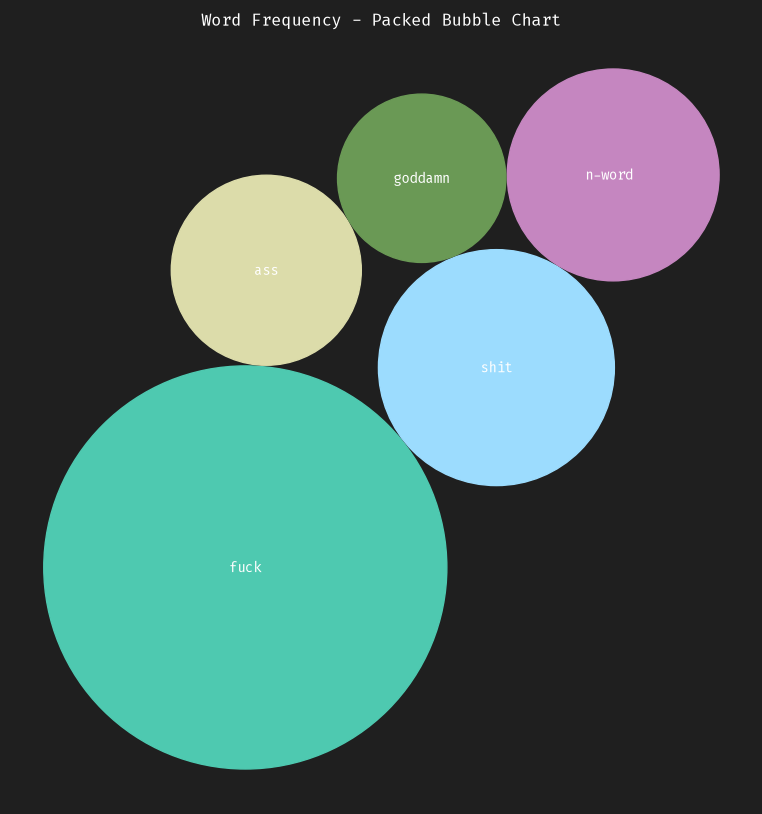

In [46]:
word_counts = (
    df[df["type"] == "word"]["word_lemma"]
    .value_counts()
    .sort_values(ascending=False)
    .head(5)
)

bubble_chart = BubbleChart(
    area=word_counts.values, bubble_spacing=0.1  # Use .values to get numpy array
)
bubble_chart.collapse()

fig, ax = plt.subplots(subplot_kw=dict(aspect="equal"), figsize=(12, 10))
bubble_chart.plot(ax, word_counts.index, palette[:5])  # Use .index for word names
ax.axis("off")
ax.relim()
ax.autoscale_view()
ax.set_title("Word Frequency - Packed Bubble Chart")

plt.show()

# Grabbing OMDB Data
This is for posterity, no longer needed because we already have the `tarantino_omdb.csv` 

In [13]:
OMDB_API_KEY = "1d018e57"

# Map Tarantino films to their IMDb IDs (avoids title ambiguity)
tarantino_films = {
    "Reservoir Dogs": "tt0105236",
    "Pulp Fiction": "tt0110912",
    "Jackie Brown": "tt0119396",
    "Kill Bill: Vol. 1": "tt0266697",
    "Kill Bill: Vol. 2": "tt0378194",
    "Inglorious Basterds": "tt0361748",
    "Django Unchained": "tt1853728",
    "The Hateful Eight": "tt3460252",
}


def get_film_info(imdb_id):
    """Fetch film data from OMDb using IMDb ID"""
    response = requests.get(
        "http://www.omdbapi.com/",
        params={"apikey": OMDB_API_KEY, "i": imdb_id, "type": "movie"},
    )
    return response.json()


# Collect data
film_data = []
for title, imdb_id in tarantino_films.items():
    info = get_film_info(imdb_id)

    # Parse box office
    box_office_raw = info.get("BoxOffice", "0").replace("$", "").replace(",", "")
    box_office_clean = float(box_office_raw) if box_office_raw else 0

    # Parse runtime (remove ' min')
    runtime_raw = info.get("Runtime", "0")
    runtime_clean = int(runtime_raw.replace(" min", "")) if runtime_raw != "N/A" else 0

    film_data.append(
        {
            "Title": info.get("Title"),
            "Year": int(info.get("Year", 0)) if info.get("Year") != "N/A" else None,
            "IMDb ID": imdb_id,
            "MPAA Rating": info.get("Rated", "N/A"),
            "Runtime (minutes)": runtime_clean,
            "Genre": info.get("Genre", "N/A"),
            "Plot": info.get("Plot", "N/A"),
            "Box Office": box_office_clean,
            "IMDb Rating": (
                float(info.get("imdbRating", 0))
                if info.get("imdbRating") != "N/A"
                else None
            ),
            "Awards": info.get("Awards", "N/A"),
            "Ratings": info.get("Ratings", []),  # List of rating sources
        }
    )

df = pd.DataFrame(film_data)


# Clean up Ratings column (extract Rotten Tomatoes, IMDb, Metacritic scores if available)
def extract_ratings(ratings_list):
    """Convert ratings list to a dict"""
    if not ratings_list:
        return {"Rotten Tomatoes": None, "IMDb": None, "Metacritic": None}

    ratings_dict = {}
    for rating in ratings_list:
        source = rating.get("Source")
        value = rating.get("Value")
        ratings_dict[source] = value
    return ratings_dict


# Expand ratings into separate columns
ratings_expanded = df["Ratings"].apply(extract_ratings).apply(pd.Series)
df = pd.concat([df, ratings_expanded], axis=1)
df = df.drop("Ratings", axis=1)  # Remove the list column

NameError: name 'requests' is not defined

In [ ]:
df.to_csv("tarantino_omdb.csv", index=False)